<a href="https://colab.research.google.com/github/PURANGANA/MarketPULSE/blob/main/MarketPULSE_(LSTM_64%2BDropout%2BLSTM_32).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Preparing metadata (setup.py) ... done
Initializing Leak-Free Framework for: TSLA


/tmp/ipykernel_599/1726950207.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START, end=END)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.5042 - loss: 0.7816 - val_accuracy: 0.5291 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5057 - loss: 0.7367 - val_accuracy: 0.5291 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5362 - loss: 0.7081 - val_accuracy: 0.5291 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5082 - loss: 0.7156 - val_accuracy: 0.5291 - val_loss: 0.6963 - learning_rate: 0.0010
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5187 - loss: 0.7097 - val_accuracy: 0.5291 - val_loss: 0.7259 - learning_rate: 0.0010
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5147 - loss: 0.7033 - val_accuracy: 0.5157 - val_loss: 0.7007 - learning_rate: 0.0010
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5207 - loss: 0.7074 - val_acc

/tmp/ipykernel_599/1726950207.py:149: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_close_price = float(df['Close'].iloc[-1])


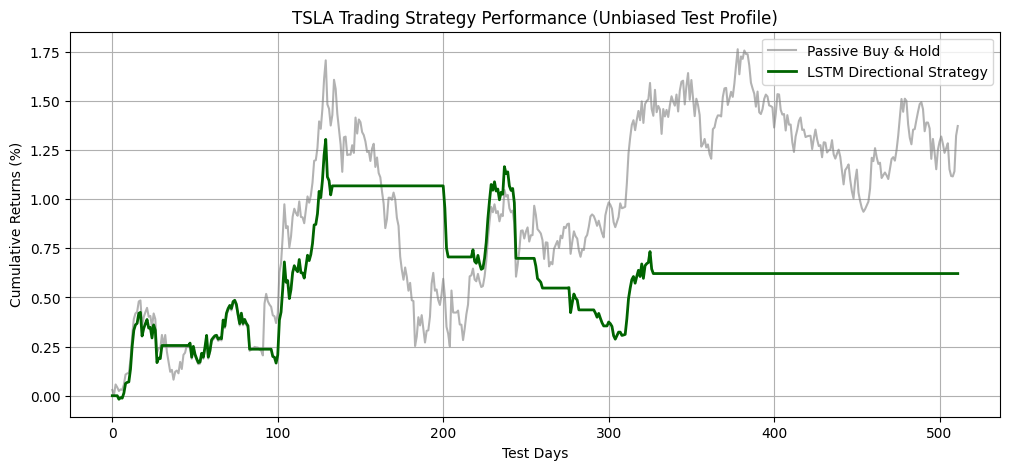

In [1]:
!pip install yfinance ta -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD
from datetime import datetime

TICKER = "TSLA"
START = "2015-01-01"
#END = datetime.today().strftime('%Y-%m-%d')
END = "2026-07-01"
SEQ_LENGTH = 60

print(f"Initializing Leak-Free Framework for: {TICKER}")

df = yf.download(TICKER, start=START, end=END)
df = df.copy()

df['Return'] = df['Close'].pct_change()

df['RSI'] = RSIIndicator(df['Close'].squeeze(), window=14).rsi()
macd_init = MACD(df['Close'].squeeze())
df['MACD_diff'] = macd_init.macd_diff()
stoch = StochasticOscillator(df['High'].squeeze(), df['Low'].squeeze(), df['Close'].squeeze())
df['Stoch'] = stoch.stoch()

df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

df = df.dropna()

features = ['Close', 'Volume', 'Return', 'RSI', 'MACD_diff', 'Stoch']

# =========================
# TEMPORAL SPLIT
# =========================
train_size = int(len(df) * 0.8)
train_df = df[:train_size].copy()
test_df = df[train_size:].copy()

# =========================
# SCALE FEATURES
# =========================
scaler = MinMaxScaler(feature_range=(0, 1))
train_features_scaled = scaler.fit_transform(train_df[features])
test_features_scaled = scaler.transform(test_df[features])

train_targets = train_df['Target'].values
test_targets = test_df['Target'].values

# =========================
# GENERATE SEQUENCES
# =========================
def create_binary_sequences(features_scaled, targets, seq_length):
    X, y = [], []

    for i in range(seq_length, len(features_scaled)):
        X.append(features_scaled[i-seq_length:i])
        y.append(targets[i-1]) # Target is already properly aligned
    return np.array(X), np.array(y)

X_train, y_train = create_binary_sequences(train_features_scaled, train_targets, SEQ_LENGTH)
X_test, y_test = create_binary_sequences(test_features_scaled, test_targets, SEQ_LENGTH)

# =========================
# ROBUST CLASSIFICATION MODEL
# =========================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Outputs probability between 0 and 1
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# TRAINING MECHANICS
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =========================
# NEXT-DAY TEST EVALUATION
# =========================

pred_probabilities = model.predict(X_test).flatten()

pred_classes = (pred_probabilities > 0.5).astype(int)

acc = accuracy_score(y_test, pred_classes)

print("\n" + "="*30)
print("     REAL-WORLD PERFORMANCE     ")
print("="*30)
print(f"Next-Day Directional Accuracy: {acc * 100:.2f}%")
print("\nClassification Matrix Metrics:")
print(classification_report(y_test, pred_classes, target_names=['Down/Flat', 'Up']))

# =========================
# PURE TOMORROW PREDICTION (LIVE OUT OF SAMPLE)
# =========================

live_window = test_features_scaled[-SEQ_LENGTH:]
tomorrow_probability = model.predict(live_window.reshape(1, SEQ_LENGTH, len(features)), verbose=0)[0, 0]

print("\n" + "="*30)
print(f"   LIVE NEXT-DAY FORECAST FOR THE NEXT SESSION   ")
print("="*30)
print(f"Probability that {TICKER} will finish HIGHER tomorrow: {tomorrow_probability * 100:.2f}%")
print(f"Actionable Model Decision: {'BUY / LONG' if tomorrow_probability > 0.5 else 'SELL / SHORT or CASH'}")
print("="*30)

# =========================================================
# PREDICTED STOCK PRICE VALUE + ACCURACY
# =========================================================

last_close_price = float(df['Close'].iloc[-1])
last_close_date = df.index[-1].date()

avg_up_return = train_df.loc[train_df['Return'] > 0, 'Return'].mean()
avg_down_return = train_df.loc[train_df['Return'] < 0, 'Return'].mean()

predicted_direction = "UP" if tomorrow_probability > 0.5 else "DOWN"
expected_move = avg_up_return if predicted_direction == "UP" else avg_down_return
predicted_price = last_close_price * (1 + expected_move)

print("\n" + "="*30)
print("   PREDICTED NEXT-DAY STOCK PRICE   ")
print("="*30)
print(f"Last Known Close ({last_close_date}): ${last_close_price:.2f}")
print(f"Predicted Direction: {predicted_direction} (Model Confidence: {tomorrow_probability * 100:.2f}%)")
print(f"Estimated Next-Day Closing Price: ${predicted_price:.2f}  "
      f"(implied move: {expected_move * 100:+.2f}%)")
print(f"Model's Historical Directional Accuracy on Test Set: {acc * 100:.2f}%")
print("="*30)

# =========================
# EQUITY CURVE VALIDATION PLOT
# =========================

test_returns = test_df['Return'].values[SEQ_LENGTH:]

strategy_returns = np.where(pred_classes == 1, test_returns, 0)

cum_bh = np.cumprod(1 + test_returns) - 1
cum_strategy = np.cumprod(1 + strategy_returns) - 1

plt.figure(figsize=(12, 5))
plt.plot(cum_bh, label="Passive Buy & Hold", color='gray', alpha=0.6)
plt.plot(cum_strategy, label="LSTM Directional Strategy", color='darkgreen', linewidth=2)
plt.title(f"{TICKER} Trading Strategy Performance (Unbiased Test Profile)")
plt.ylabel("Cumulative Returns (%)")
plt.xlabel("Test Days")
plt.legend()
plt.grid(True)
plt.show()
